## 1. Importar librerías

In [42]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import cv2

## 2. Cargar el dataset Fashion MNIST

In [43]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

## 3. Información general del dataset

In [44]:
print("Imágenes de entrenamiento:", train_images.shape)
print("Etiquetas de entrenamiento:", train_labels.shape)
print("Imágenes de prueba:", test_images.shape)
print("Etiquetas de prueba:", test_labels.shape)

Imágenes de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Imágenes de prueba: (10000, 28, 28)
Etiquetas de prueba: (10000,)


## 4. Nombres de las clases

El dataset contiene 10 categorías diferentes de ropa.

In [45]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

## 5. Visualización de imágenes del dataset

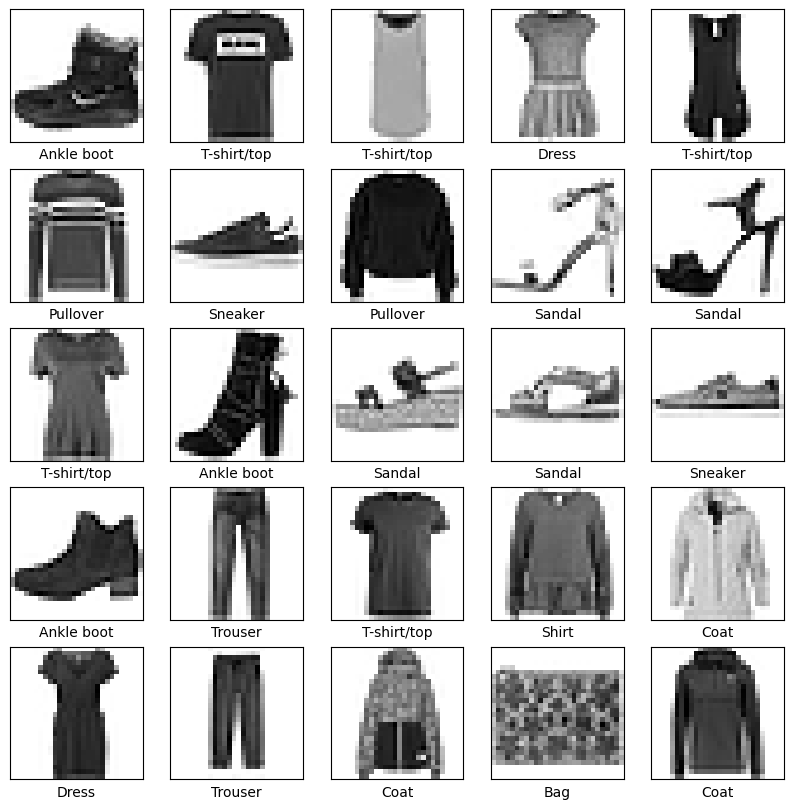

In [46]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])

plt.show()

## 6. Aplicación de filtros en una imagen del dataset

En esta parte se aplican filtros básicos para observar mejor los bordes y detalles de una prenda. Esto sirve para entender mejor cómo se pueden extraer características visuales de una imagen.

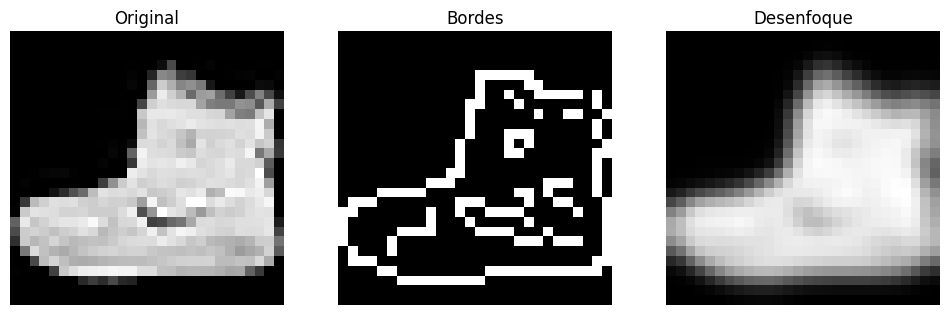

In [47]:
# Tomar una imagen del dataset
imagen = train_images[0]

# Convertir la imagen a formato uint8
imagen_uint8 = imagen.astype('uint8')

# Aplicar filtro de bordes Canny
bordes = cv2.Canny(imagen_uint8, 50, 150)

# Aplicar desenfoque Gaussiano
blur = cv2.GaussianBlur(imagen_uint8, (5,5), 0)

# Mostrar resultados
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagen_uint8, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bordes, cmap='gray')
plt.title("Bordes")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blur, cmap='gray')
plt.title("Desenfoque")
plt.axis("off")

plt.show()

## 7. Normalización de imágenes

Las imágenes originalmente tienen valores entre 0 y 255. Para que la red neuronal trabaje mejor, se convierten esos valores a un rango entre 0 y 1.

In [48]:
train_images = train_images / 255.0
test_images = test_images / 255.0

## 8. Crear el modelo de red neuronal

Este primer modelo es una red neuronal básica. Para una versión final se puede mejorar usando una red neuronal convolucional.

In [49]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 9. Compilar el modelo

In [50]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 10. Entrenar la red neuronal

In [51]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8167 - loss: 0.5200 - val_accuracy: 0.8480 - val_loss: 0.4303
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8586 - loss: 0.3882 - val_accuracy: 0.8664 - val_loss: 0.3666
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8736 - loss: 0.3448 - val_accuracy: 0.8574 - val_loss: 0.3926
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8808 - loss: 0.3221 - val_accuracy: 0.8653 - val_loss: 0.3600
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8888 - loss: 0.2997 - val_accuracy: 0.8626 - val_loss: 0.3932
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8950 - loss: 0.2828 - val_accuracy: 0.8828 - val_loss: 0.3213
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8990 - loss: 0.2728 - val_accuracy: 0.8840 - val_loss: 0.3222
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9030 - loss: 0.2612

In [52]:

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)

print("Pérdida del modelo:", round(test_loss, 4))
print("Porcentaje de efectividad del modelo:", round(test_acc * 100, 2), "%")

Pérdida del modelo: 0.3684
Porcentaje de efectividad del modelo: 86.84 %


## 11. Evaluar el modelo

In [53]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Precisión del modelo:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8684 - loss: 0.3684
Precisión del modelo: 0.868399977684021


## 12. Gráfica de precisión y pérdida

Estas gráficas ayudan a observar cómo fue aprendiendo el modelo durante el entrenamiento.

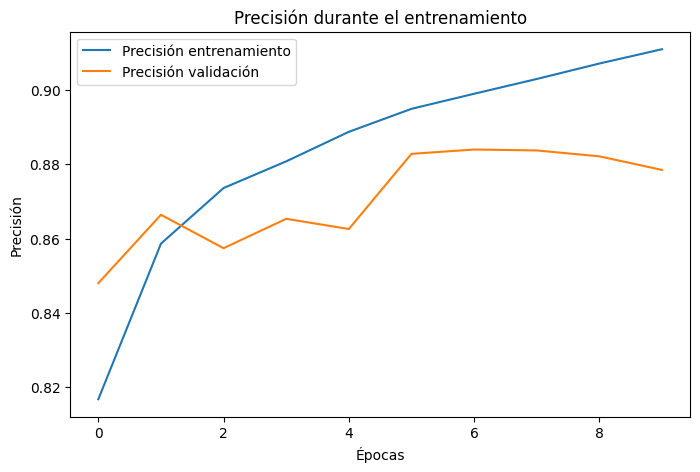

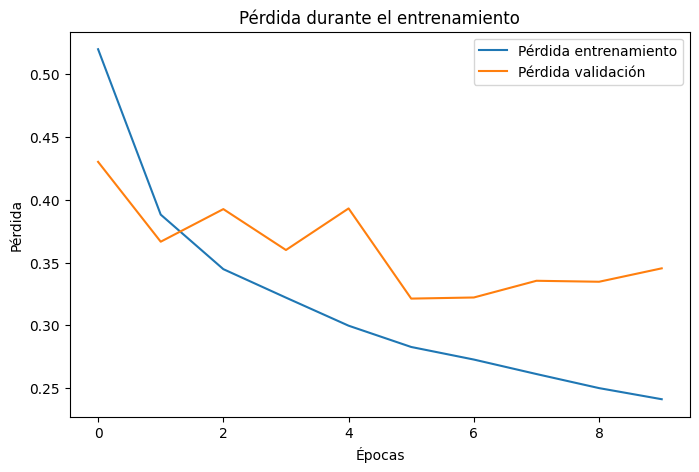

In [54]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Precisión entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

## 13. Realizar predicciones con imágenes de prueba

In [55]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### 14. Probar una imagen del dataset

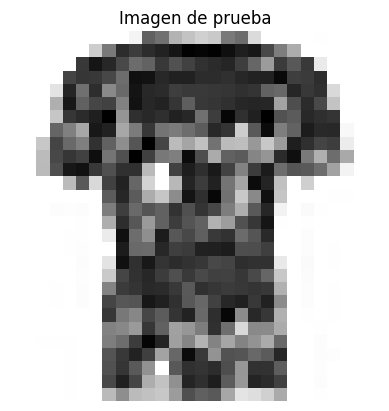

Predicción: T-shirt/top
Valor real: T-shirt/top


In [56]:
numero_imagen = 400

plt.imshow(test_images[numero_imagen], cmap=plt.cm.binary)
plt.title("Imagen de prueba")
plt.axis("off")
plt.show()

print("Predicción:", class_names[np.argmax(predictions[numero_imagen])])
print("Valor real:", class_names[test_labels[numero_imagen]])

## 15. Subir una imagen propia

En esta sección se puede subir una imagen desde la computadora para procesarla y probarla con el modelo.


In [64]:
from google.colab import files

uploaded = files.upload()

Saving images (6).jpg to images (6).jpg


## 16. Procesar imagen subida con mejor preprocesamiento

Cuando se usa una imagen tomada de internet o desde una cámara, no se puede reducir directamente a 28x28 porque se pierde mucha información y el modelo puede confundirse.

En esta sección se prepara la imagen para que se parezca más al formato de Fashion MNIST:

- Se convierte a escala de grises.
- Se separa el objeto del fondo.
- Se recorta la prenda principal.
- Se centra en un fondo negro.
- Se convierte a 28x28 píxeles.
- Se muestran filtros para entender mejor la imagen.


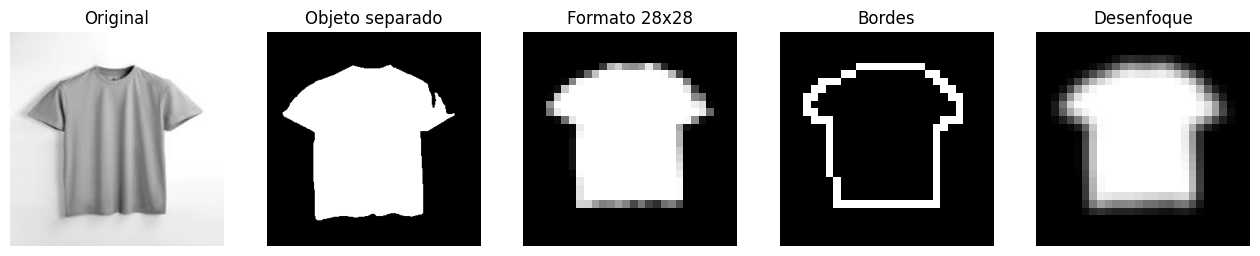

In [65]:

# Tomar el nombre del primer archivo subido
nombre_imagen = list(uploaded.keys())[0]

# Leer imagen en escala de grises
img_original = cv2.imread(nombre_imagen, cv2.IMREAD_GRAYSCALE)

# Verificar que la imagen se haya cargado correctamente
if img_original is None:
    raise ValueError("No se pudo leer la imagen. Verifica que el archivo sea una imagen válida.")

# Redimensionar la imagen a un tamaño manejable antes del procesamiento
img = cv2.resize(img_original, (300, 300))

# Suavizar la imagen para reducir ruido
blur = cv2.GaussianBlur(img, (5, 5), 0)

# Umbral automático con Otsu
_, umbral = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Detectar si el fondo es claro u oscuro usando las esquinas
esquinas = np.concatenate([
    img[:30, :30].ravel(),
    img[:30, -30:].ravel(),
    img[-30:, :30].ravel(),
    img[-30:, -30:].ravel()
])

promedio_fondo = np.mean(esquinas)

# Fashion MNIST normalmente tiene fondo negro y objeto claro.
# Si el fondo de la imagen es claro, invertimos para que el objeto quede blanco.
if promedio_fondo > 127:
    mascara = cv2.bitwise_not(umbral)
else:
    mascara = umbral.copy()

# Limpiar pequeños puntos de ruido
kernel = np.ones((3, 3), np.uint8)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

# Encontrar contornos del objeto principal
contornos, _ = cv2.findContours(
    mascara,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contornos) == 0:
    raise ValueError("No se encontró un objeto claro en la imagen. Intenta usar una imagen con fondo más limpio.")

# Tomar el contorno más grande
contorno_principal = max(contornos, key=cv2.contourArea)

# Obtener caja que encierra el objeto
x, y, w, h = cv2.boundingRect(contorno_principal)

# Recortar únicamente el objeto
objeto = mascara[y:y+h, x:x+w]

# Redimensionar manteniendo proporción para no deformar demasiado la prenda
alto, ancho = objeto.shape

if alto > ancho:
    nuevo_alto = 22
    nuevo_ancho = int((ancho / alto) * nuevo_alto)
else:
    nuevo_ancho = 22
    nuevo_alto = int((alto / ancho) * nuevo_ancho)

objeto_redimensionado = cv2.resize(
    objeto,
    (nuevo_ancho, nuevo_alto),
    interpolation=cv2.INTER_AREA
)

# Crear lienzo negro de 28x28 como Fashion MNIST
img_28 = np.zeros((28, 28), dtype=np.uint8)

# Centrar el objeto en el lienzo
x_offset = (28 - nuevo_ancho) // 2
y_offset = (28 - nuevo_alto) // 2

img_28[y_offset:y_offset+nuevo_alto, x_offset:x_offset+nuevo_ancho] = objeto_redimensionado

# Aplicar filtros para observar características
bordes = cv2.Canny(img_28, 50, 150)
desenfoque = cv2.GaussianBlur(img_28, (3, 3), 0)

# Normalizar imagen final para la red neuronal
img_final = img_28 / 255.0

# Mostrar todo el proceso
plt.figure(figsize=(16, 4))

plt.subplot(1, 5, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(mascara, cmap='gray')
plt.title("Objeto separado")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(img_28, cmap='gray')
plt.title("Formato 28x28")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(bordes, cmap='gray')
plt.title("Bordes")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(desenfoque, cmap='gray')
plt.title("Desenfoque")
plt.axis("off")

plt.show()


## 17. Clasificar imagen subida

Después del preprocesamiento, la imagen ya queda en un formato más parecido al dataset Fashion MNIST.  
Además de mostrar la predicción principal, se muestran las 3 clases con mayor probabilidad para analizar si el modelo está dudando entre categorías similares.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicción principal: T-shirt/top
Confianza: 49.24 %

Top 3 predicciones:
T-shirt/top: 49.24%
Shirt: 41.03%
Bag: 7.99%


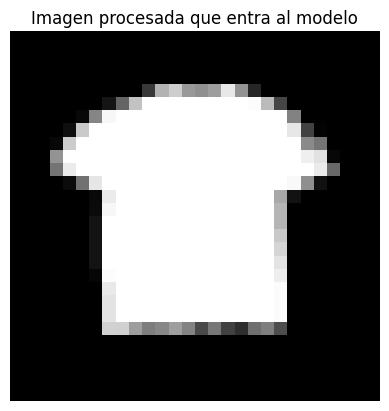

In [66]:
# Ajustar dimensiones para que el modelo pueda hacer la predicción
img_pred = np.expand_dims(img_final, axis=0)

# Realizar predicción
prediccion = model.predict(img_pred)

# Obtener clase con mayor probabilidad
clase_predicha = np.argmax(prediccion)
confianza = np.max(prediccion) * 100

print("Predicción principal:", class_names[clase_predicha])
print("Confianza:", round(confianza, 2), "%")

# Mostrar las 3 predicciones más probables
top_3 = np.argsort(prediccion[0])[-3:][::-1]

print("\nTop 3 predicciones:")
for i in top_3:
    print(f"{class_names[i]}: {prediccion[0][i] * 100:.2f}%")

# Mostrar imagen final que realmente analiza la red
plt.imshow(img_final, cmap='gray')
plt.title("Imagen procesada que entra al modelo")
plt.axis("off")
plt.show()




313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<Figure size 1000x1000 with 0 Axes>

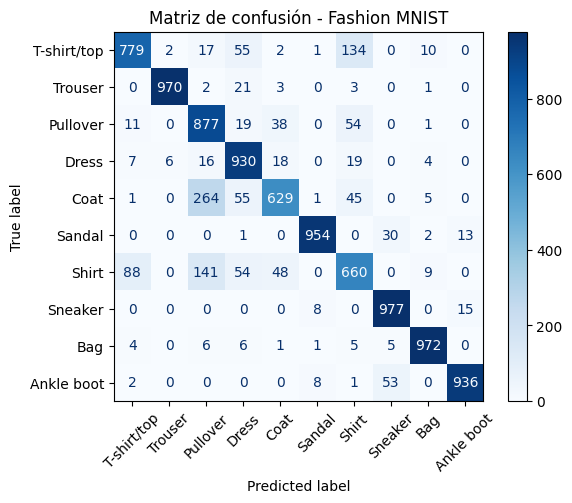

In [60]:

# Predicciones del modelo
predicciones = model.predict(test_images)

# Convertir probabilidades a clases
predicciones_clases = np.argmax(predicciones, axis=1)

# Crear matriz de confusión
matriz = confusion_matrix(test_labels, predicciones_clases)

# Mostrar matriz
plt.figure(figsize=(10,10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de confusión - Fashion MNIST")
plt.show()